In [2]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plotting
from matplotlib import cm  # Colormaps
from matplotlib import gridspec
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

In [3]:
plt.rcParams.update({'font.size': 22})
base_dir = os.getcwd()

save_dir = os.path.join(base_dir, "graphs")
output_data_ex1 = os.path.join(base_dir,  "Experiment1_Pedagogical", "output_data")
data_dir_ex2 = os.path.join(base_dir,  "Experiment2_Tripendulum", "output_data")
sim_data_dir_ex2 = os.path.join(base_dir,  "Experiment2_Tripendulum", "input_data")
output_data_ex3 = os.path.join(base_dir, "Experiment3_Magnetostatics", "output_data")

torch.Size([5000, 4])
(1000,)


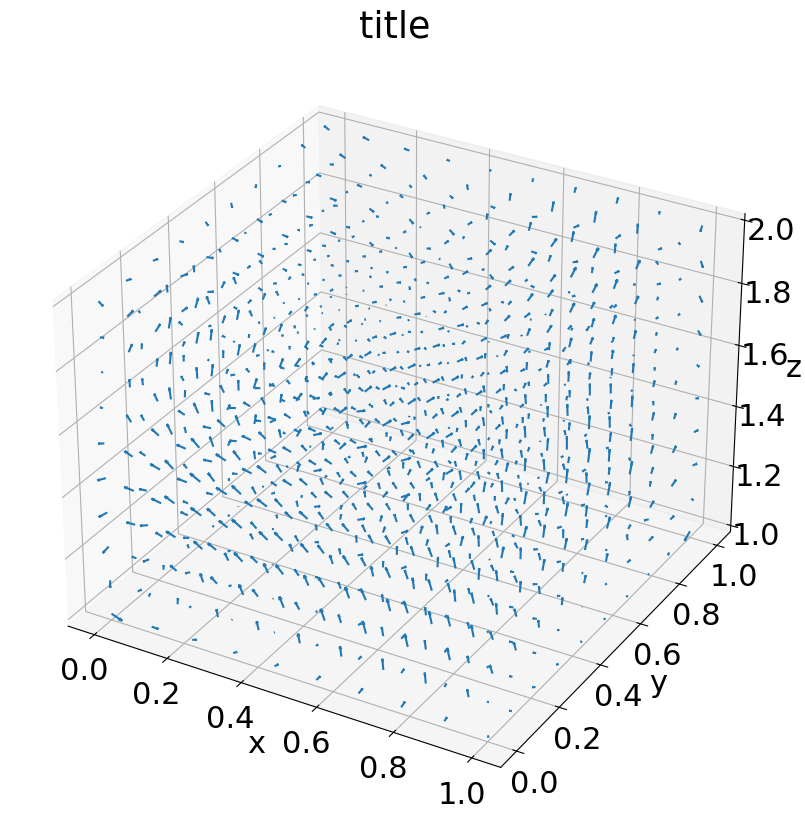

In [62]:
output_data_ex3 = os.path.join(base_dir, "Experiment3_Magnetostatics", "output_data")
def plot_3d_scatter(values,  title):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    mask = ~torch.isnan(values)

    ax.scatter(
        train_x[mask, 0].numpy(),
        train_x[mask, 1].numpy(),
        train_x[mask, 2].numpy(),
    )

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def plot_quiver_3d(train_x, train_y, title="Vector field"):
    fig = plt.figure(figsize = (10, 10))
    ax = fig.add_subplot(111, projection='3d')


    X = train_x[train_x[:,-1] == 0][:,0].numpy()
    Y = train_x[train_x[:,-1] == 0][:,1].numpy()
    Z = train_x[train_x[:,-1] == 0][:,2].numpy()
    
    U = train_y[train_x[:,-1] == 0].numpy()
    print(U.shape)
    V = train_y[train_x[:,-1] == 1].numpy()
    W = train_y[train_x[:,-1] == 2].numpy()

    
    ax.quiver(X, Y, Z, U, V, W)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(title)

    plt.show()



data_path = os.path.join(output_data_ex3, "Ex3_test.npz")
data = np.load(data_path)
for key in data:
    globals()[key] = torch.tensor(data[key])
print(test_x.shape)
plot_quiver_3d(test_x, mean*50, "title")

# Experiment 1: Pedagogical example

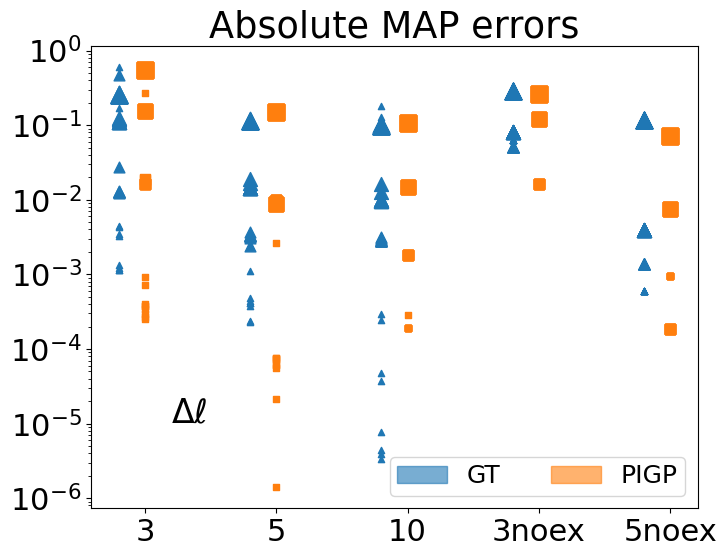

In [78]:
runs = 10

sigma_list = [0.0, 0.01, 0.1, 0.2]
n_list = [3, 5, 10,  30, 50]
modes = ["GT", "PIGP"]
all_AE = np.zeros((len(n_list), len(sigma_list), len(modes), 1, runs))



for n_idx, npoints in enumerate(n_list):
    for sigma_idx, sigma in enumerate(sigma_list):
        for j, mode in enumerate(modes):
            for run in range(runs):
                if npoints == 30:
                    data_path_ex1 = os.path.join(output_data_ex1, "Ex1_n%i_sigma%.2f_%s_%s.npz"%(3, sigma, mode, "inverse"))
                elif npoints == 50:
                    data_path_ex1 = os.path.join(output_data_ex1, "Ex1_n%i_sigma%.2f_%s_%s.npz"%(5, sigma, mode, "inverse"))
                else:
                    data_path_ex1 = os.path.join(output_data_ex1, "Ex1_n%i_sigma%.2f_%s_%s_%i.npz"%(npoints, sigma, mode, "inverse_extra", run))
                data_ex1 = np.load(data_path_ex1)
                parameters_during_training = data_ex1["parameters_during_training"]
                used_parameters = data_ex1["parameter_order"]
                for i, key in enumerate(used_parameters):
                    if key == "a":
                        learned_parameters = parameters_during_training[i, -1]
                
                all_AE[n_idx, sigma_idx, j, 0, run] = abs(learned_parameters-2.) 
                
#for plotting
width = 0.05
group_spacing = 0.3
num_boxes_per_group = 4
scale_factor = 40
base_size = 20
symbol = ["^", "s",]
markers = ["x", "+", 1/np.sqrt(2), 1]
colors = list(mcolors.TABLEAU_COLORS.values())

fig = plt.figure(figsize=(18, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 2], wspace=0.3)

# --- LEFT AXIS: split into 2 rows ---
gs_left = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=gs[0, 0], hspace=0.05)
ax00 = fig.add_subplot(gs_left[0, 0])  # top subplot



# --- LEFT TOP: parameter = l
for n_idx, n in enumerate(n_list):
    group_pos = n_idx * (num_boxes_per_group * width + group_spacing)
    for mode in range(2):  # j=0,1
        pos = group_pos + 2 * mode * width
        for sigma_idx, sigma in enumerate(sigma_list):
            data = all_AE[n_idx, sigma_idx, mode, 0]
            x_vals = np.full(len(data), pos)
            marker_size = base_size + scale_factor * sigma_idx
            ax00.scatter(x_vals, data,
                         marker=symbol[mode], color=colors[mode % len(colors)],
                         alpha=1., s=marker_size,
                         label=f'σ={sigma:.2f}' if n_idx == 0 and j == 0 else None)
        
ax00.text(0.2, 1e-5, r"""$\Delta \ell$""", fontsize=24)
AE_xtick_positions = [i * (num_boxes_per_group * width + group_spacing) + width*num_boxes_per_group/2 for i in range(len(n_list))]
AE_xtick_labels = ["3", "5", "10",  "3noex", "5noex"]#["3ex " if n == 30 elif "5ex" if n == 50 else f"{n}" for n in n_list]
ax00.set_xticks(AE_xtick_positions, AE_xtick_labels)
   
ax00.set_title("Absolute MAP errors")
ax00.set_yscale("log")
#legend
import matplotlib.patches as mpatches
gt_patch = mpatches.Patch(color=colors[0], label="GT", alpha=0.6)
pigp_patch = mpatches.Patch(color=colors[1], label="PIGP", alpha=0.6)
ax00.legend(handles=[gt_patch, pigp_patch], ncols = 2, fontsize = 18, borderpad = 0.3)

#plt.savefig(os.path.join(save_dir, "Ex1_metrics.pdf"), bbox_inches='tight' )#dpi=300,

In [82]:
npoints = 15
sigma_list = [0.0, 0.01, 0.1, 0.2]
modes = ["GT", "PIGP"]


print("GT    PIGP")
for sigma_idx, sigma in enumerate(sigma_list):
        GT = np.load(os.path.join(output_data_ex1, "Ex1_n%i_sigma%.2f_%s_%s_%i.npz"%(npoints, sigma, "GT", "inverse_extra", 0)))
        err_GT = GT["a"]-2
        PIGP = np.load(os.path.join(output_data_ex1, "Ex1_n%i_sigma%.2f_%s_%s_%i.npz"%(npoints, sigma, "PIGP", "inverse_extra", 0)))
        err_PIGP = PIGP["a"]-2
        print(sigma, abs(err_GT[-1]), abs(err_PIGP[-1]))

GT    PIGP
0.0 [0.00021401] [0.09726736]
0.01 [0.00373484] [0.1926849]
0.1 [0.00604743] [0.04275902]
0.2 [0.05492139] [0.06716608]


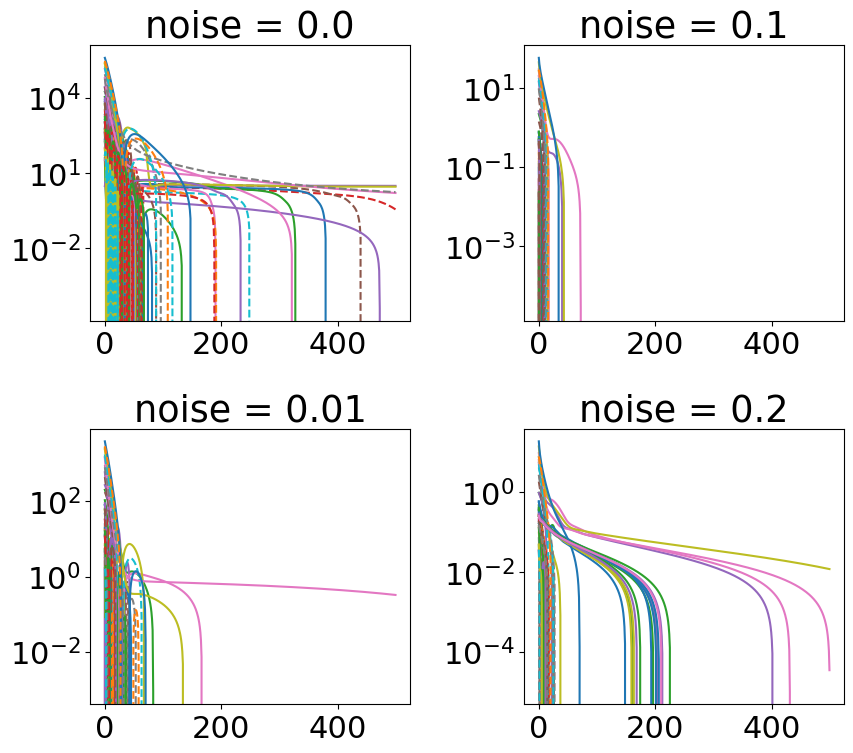

In [41]:




sigma_list = [0.0, 0.01, 0.1, 0.2]
npoints_list = [3, 5, 10]

modes = ["GT", "PIGP"]
linestyle = {"GT": "-", "PIGP":"--"}
colors = ["C0","C1","C2","C3", "C4", "C5", "C6", "C7"]
linestyle = {"GT":"-", "PIGP":"--"}
index = {"GT": -1, "PIGP":0}
fig, ax = plt.subplots(2,2, figsize = (9, 8))
for run in range(10):
    for j in range(len(sigma_list)):
        sigma = sigma_list[j]
        
        for i in range(3):
            npoints = npoints_list[i]
            for sol_mode in modes:
                
                data_ex2 = np.load(os.path.join(output_data_ex1, "Ex1_n%i_sigma%.2f_%s_%s_%i.npz"%(npoints, sigma, sol_mode, "inverse_extra", run)))
                
                parameters_during_training = data_ex2["parameters_during_training"]
                used_parameters = data_ex2["parameter_order"]
                loss = data_ex2["loss"]
                #print(used_parameters)
                ind = index[sol_mode]
                #print(ind)
                #for k in range(ind, ind+1):# len(used_parameters)):
                #    ax[j%2, j//2].plot(range(len(parameters_during_training[0,:])), parameters_during_training[k,:], linestyle = linestyle[sol_mode], label = used_parameters[k])
                ax[j%2, j//2].plot(range(len(parameters_during_training[0,:])), loss, linestyle = linestyle[sol_mode], )

                #.plot(range(len(lengthscale)), g/length, linestyle[mode], color = colors[i], label = f" n={npoints}", alpha = 0.3)
        ax[j%2, j//2].set_title(f"noise = {sigma}")
        #ax[j%2, j//2].plot(range(len(lengthscale)), 2.5*np.ones_like(g), "r-.")
       
        #ax[j%2, j//2].set_ylim((0, 1))
        ax[j%2, j//2].set_yscale("log")
        
plt.tight_layout()
#plt.savefig(os.path.join(save_dir,"Ex2_convergence.pdf"), dpi = 300)
    #plt.legend()


In [37]:
(15*15*4)**3/(15*15*3)**3

2.3703703703703702

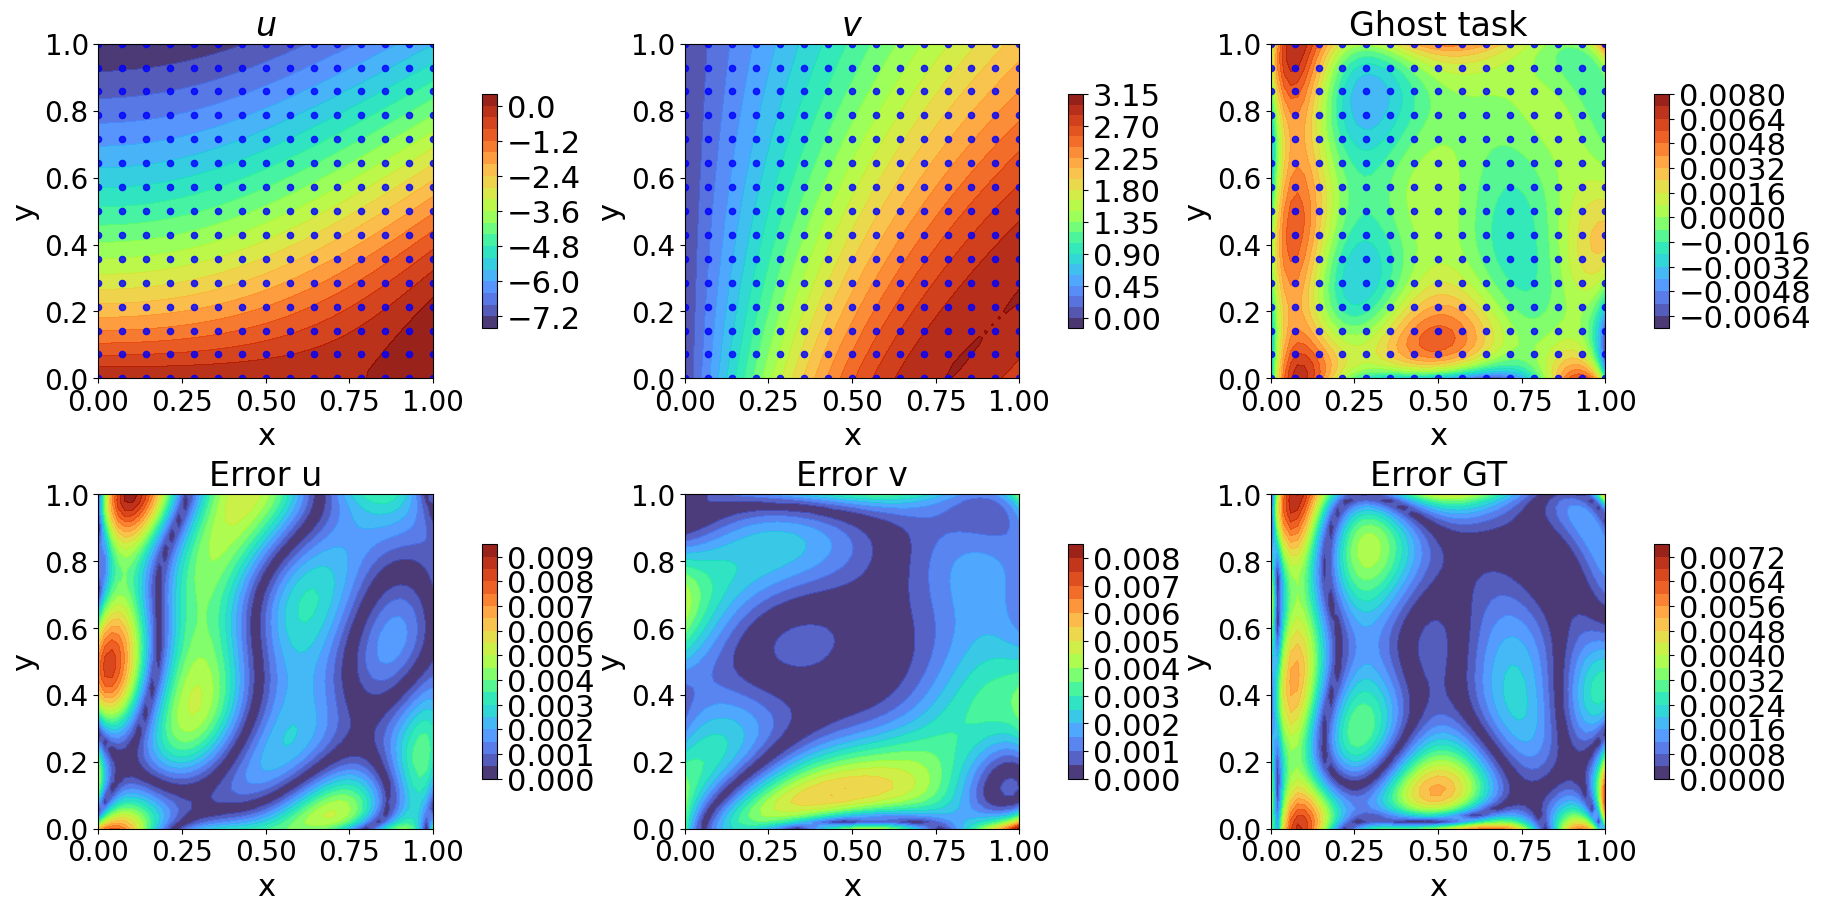

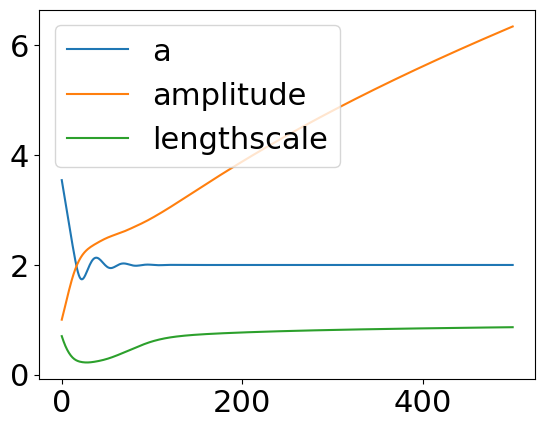

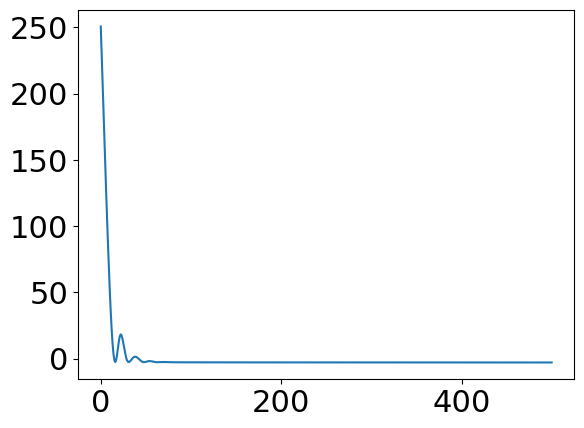

In [71]:
npoints = 15
sigma = 0.01
mode ="inverse_extra" #or "inverse"
sol_mode = "GT" #or "PIGP"
data_path_ex1 = os.path.join(output_data_ex1, "Ex1_n%i_sigma%.2f_%s_%s_%i.npz"%(npoints, sigma, sol_mode, mode, 0))
data_ex1 = np.load(data_path_ex1)
for key in data_ex1:
        globals()[key] = torch.tensor(data_ex1[key])

u = mean[test_x[:,-1] == 0].reshape(51, 51)
v = mean[test_x[:,-1] == 1].reshape(51, 51)
GT = mean[test_x[:,-1] == 2].reshape(51, 51)
error = []
outputs = [u, v, GT]
error = [u-test_y[test_x[:,-1] == 0].reshape(51, 51), v-test_y[test_x[:,-1] == 1].reshape(51, 51), GT]
x = test_x[:,0][test_x[:,-1] == 2].reshape(51, 51)
y = test_x[:,1][test_x[:,-1] == 2].reshape(51, 51)
fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)

plots = [
    (u, r"$u$", "turbo", 0),
    (v, r"$v$", "turbo", 1),
    (GT, "Ghost task", "turbo", 2),
    (abs(error[0]), "Error u", "turbo", 3),
    (abs(error[1]), "Error v", "turbo", 4),
 (abs(error[2]), "Error GT", "turbo", 5),
]

for ax, (Z, title, cmap, k) in zip(axes.flat, plots):
    surf = ax.contourf(x, y, Z, cmap=cmap, levels=20, alpha=0.9)
    fig.colorbar(surf, ax=ax, shrink=0.7, aspect=15)

    # Training points
    if k<3:
        mask = train_x[:,-1] == k  
        #print(train_x[:,0][mask].shape)
        ax.scatter(train_x[mask, 0], train_x[mask, 1], color="blue", s=20, alpha=0.8)

    # Labels and title
    ax.set_title(title, fontsize=24)
    ax.set_xlabel("x", fontsize=22)
    ax.set_ylabel("y", fontsize=22)
    ax.set_aspect("equal")
    ax.tick_params(axis="both", labelsize=20)
#plt.savefig(os.path.join(save_dir, "Ex1_n%i_sigma%.2f_%s_%s.pdf"%(npoints, sigma, sol_mode, mode)), bbox_inches='tight')# dpi=300,

plt.figure()
for key in ["a", "amplitude", "lengthscale"]:
    param = data_ex1[key]
    plt.plot(range(len(param)), param, label=key)
plt.legend()
plt.figure()
plt.plot(range(len(loss)), loss)


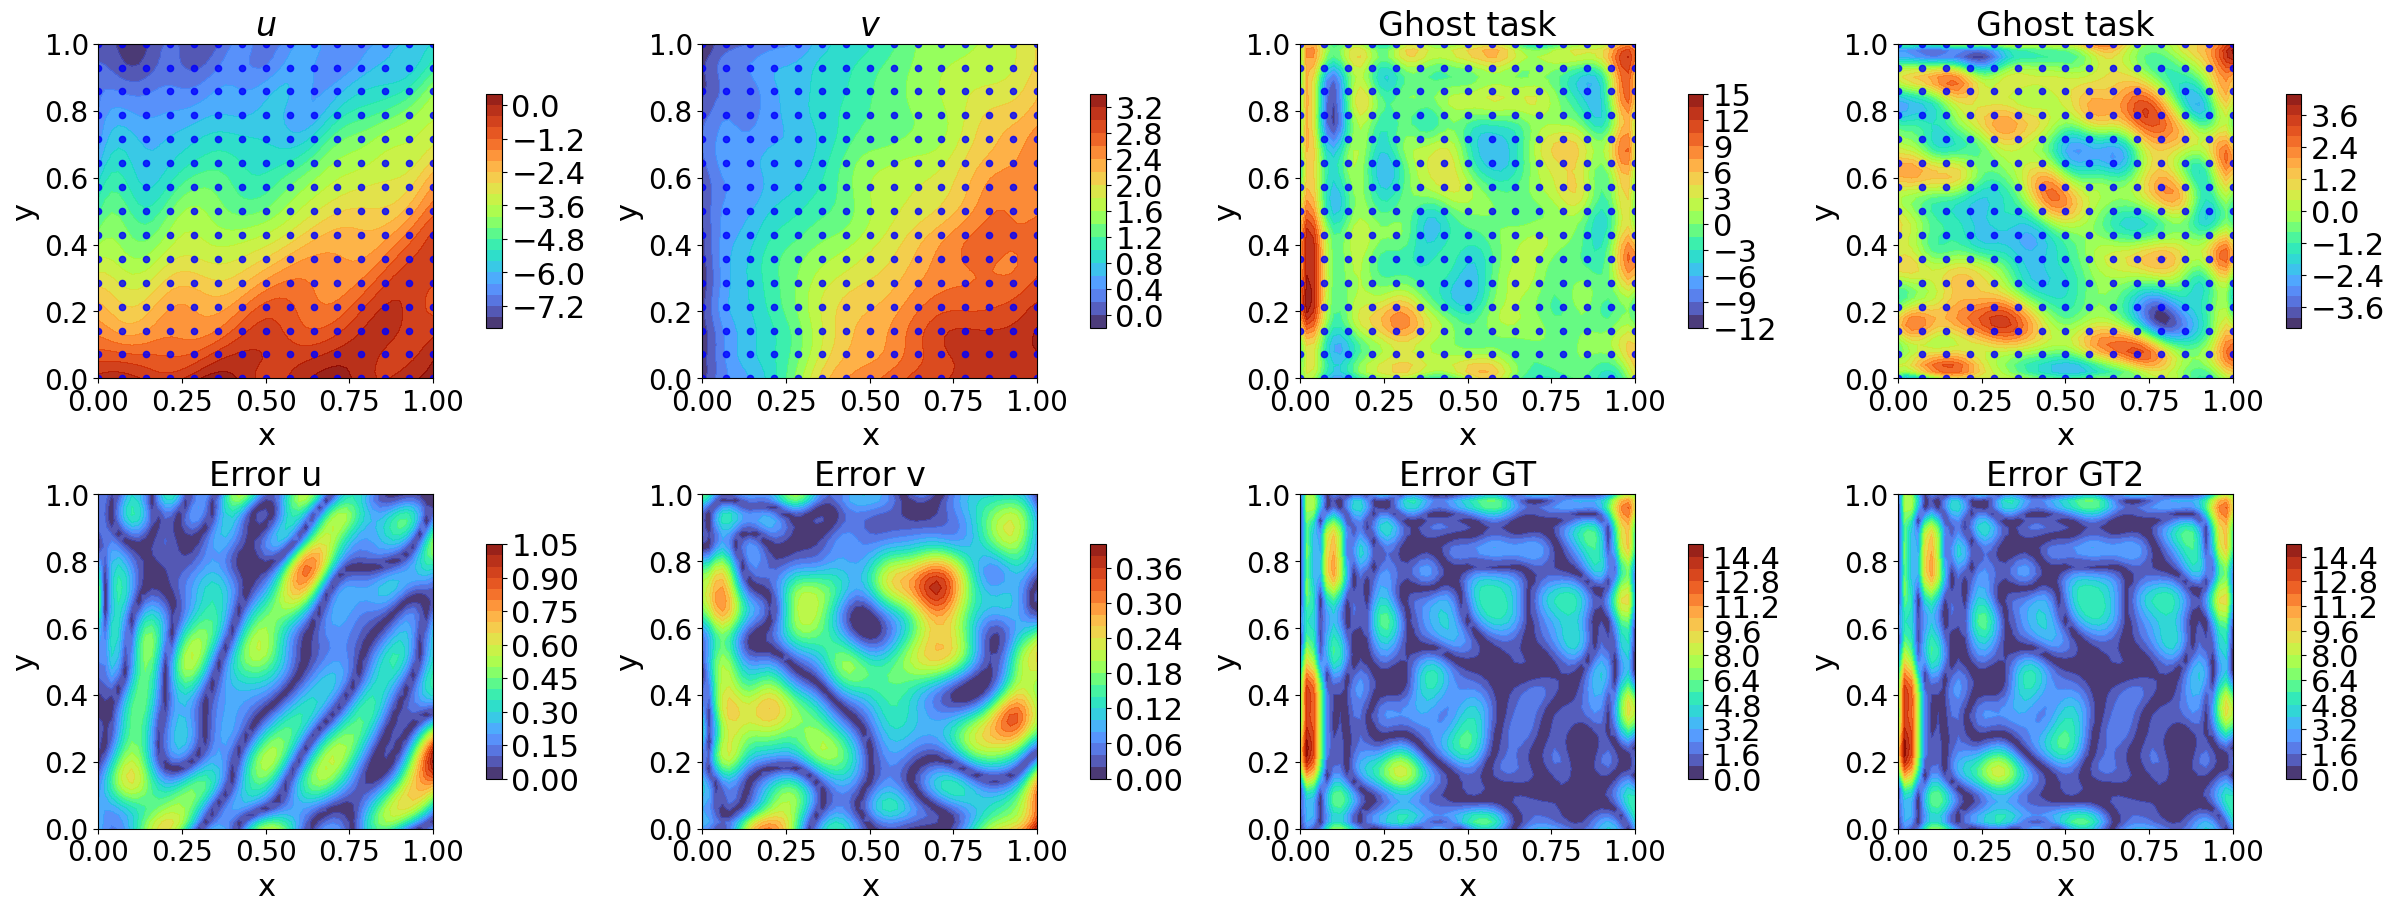

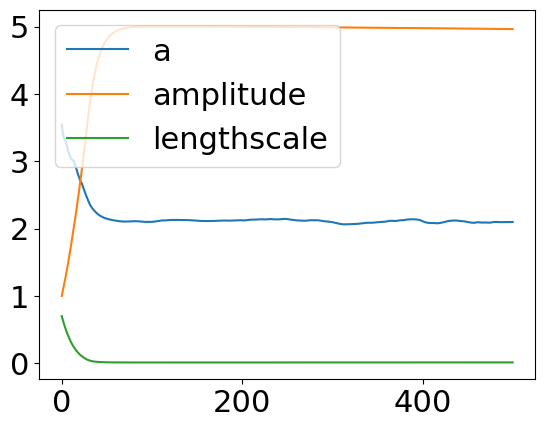

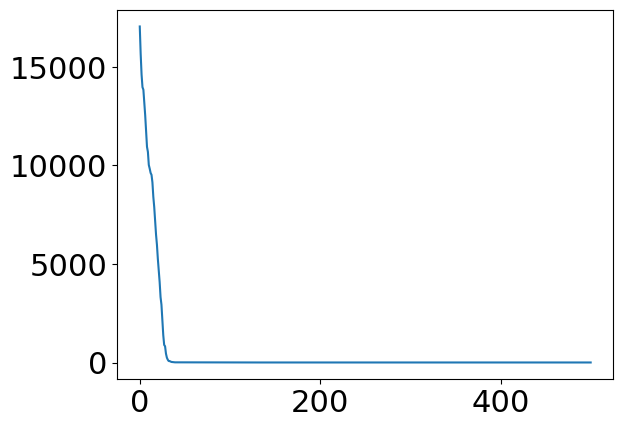

In [76]:
npoints = 15
sigma = 0.001
mode ="inverse_extra" #or "inverse"
sol_mode = "PIGP" #or "PIGP"
data_path_ex1 = os.path.join(output_data_ex1, "Ex1_n%i_sigma%.2f_%s_%s_%i.npz"%(npoints, sigma, sol_mode, mode, 0))
data_ex1 = np.load(data_path_ex1)
for key in data_ex1:
        globals()[key] = torch.tensor(data_ex1[key])

u = mean[test_x[:,-1] == 0].reshape(51, 51)
v = mean[test_x[:,-1] == 1].reshape(51, 51)
GT = mean[test_x[:,-1] == 2].reshape(51, 51)
GT2 = mean[test_x[:,-1] == 3].reshape(51, 51)
error = []
outputs = [u, v, GT, GT2]
error = [u-test_y[test_x[:,-1] == 0].reshape(51, 51), v-test_y[test_x[:,-1] == 1].reshape(51, 51), GT, GT2]
x = test_x[:,0][test_x[:,-1] == 2].reshape(51, 51)
y = test_x[:,1][test_x[:,-1] == 2].reshape(51, 51)
fig, axes = plt.subplots(2, 4, figsize=(24, 9), constrained_layout=True)

plots = [
    (u, r"$u$", "turbo", 0),
    (v, r"$v$", "turbo", 1),
    (GT, "Ghost task", "turbo", 2),
    (GT2, "Ghost task", "turbo", 3),
    (abs(error[0]), "Error u", "turbo", 4),
    (abs(error[1]), "Error v", "turbo", 5),
 (abs(error[2]), "Error GT", "turbo", 6),
     (abs(error[2]), "Error GT2", "turbo", 7),
]

for ax, (Z, title, cmap, k) in zip(axes.flat, plots):
    surf = ax.contourf(x, y, Z, cmap=cmap, levels=20, alpha=0.9)
    fig.colorbar(surf, ax=ax, shrink=0.7, aspect=15)

    # Training points
    if k<4:
        mask = train_x[:,-1] == k  
        #print(train_x[:,0][mask].shape)
        ax.scatter(train_x[mask, 0], train_x[mask, 1], color="blue", s=20, alpha=0.8)

    # Labels and title
    ax.set_title(title, fontsize=24)
    ax.set_xlabel("x", fontsize=22)
    ax.set_ylabel("y", fontsize=22)
    ax.set_aspect("equal")
    ax.tick_params(axis="both", labelsize=20)
plt.savefig(os.path.join(save_dir, "Ex1_n%i_sigma%.2f_%s_%s.pdf"%(npoints, sigma, sol_mode, mode)), bbox_inches='tight')# dpi=300,


plt.figure()
for key in ["a", "amplitude", "lengthscale"]:
    param = data_ex1[key]
    plt.plot(range(len(param)), param, label=key)
plt.legend()
plt.figure()
plt.plot(range(len(loss)), loss)


In [ ]:
##########old version for n3 n5 n10

npoints = 5
sigma = 0.001
mode ="inverse" #or "inverse"
sol_mode = "PIGP" #or "PIGP"
data_path_ex1 = os.path.join(output_data_ex1, "Ex1_n%i_sigma%.2f_%s_%s.npz"%(npoints, sigma, sol_mode, mode))
data_ex1 = np.load(data_path_ex1)
for key in data_ex1:
    if key != "parameter_order":
        globals()[key] = torch.tensor(data_ex1[key])
        
used_parameters = data_ex1["parameter_order"]
for i, key in enumerate(used_parameters):
    print(key, "%.6f"%parameters_during_training[i, -1])

u = mean[test_x[:,-1] == 0].reshape(51, 51)
v = mean[test_x[:,-1] == 1].reshape(51, 51)
GT = mean[test_x[:,-1] == 2].reshape(51, 51)
GT2 = mean[test_x[:,-1] == 3].reshape(51, 51)
error = []
outputs = [u, v, GT, GT2]
error = [u-test_y[test_x[:,-1] == 0].reshape(51, 51), v-test_y[test_x[:,-1] == 1].reshape(51, 51), GT, GT2]
x = test_x[:,0][test_x[:,-1] == 2].reshape(51, 51)
y = test_x[:,1][test_x[:,-1] == 2].reshape(51, 51)
fig, axes = plt.subplots(2, 4, figsize=(24, 9), constrained_layout=True)

plots = [
    (u, r"$u$", "turbo", 0),
    (v, r"$v$", "turbo", 1),
    (GT, "Ghost task", "turbo", 2),
    (GT2, "Ghost task", "turbo", 3),
    (abs(error[0]), "Error u", "turbo", 4),
    (abs(error[1]), "Error v", "turbo", 5),
 (abs(error[2]), "Error GT", "turbo", 6),
     (abs(error[2]), "Error GT2", "turbo", 7),
]

for ax, (Z, title, cmap, k) in zip(axes.flat, plots):
    surf = ax.contourf(x, y, Z, cmap=cmap, levels=20, alpha=0.9)
    fig.colorbar(surf, ax=ax, shrink=0.7, aspect=15)

    # Training points
    if k<4:
        mask = train_x[:,-1] == k  
        #print(train_x[:,0][mask].shape)
        ax.scatter(train_x[mask, 0], train_x[mask, 1], color="blue", s=20, alpha=0.8)

    # Labels and title
    ax.set_title(title, fontsize=24)
    ax.set_xlabel("x", fontsize=22)
    ax.set_ylabel("y", fontsize=22)
    ax.set_aspect("equal")
    ax.tick_params(axis="both", labelsize=20)
plt.savefig(os.path.join(save_dir, "Ex1_n%i_sigma%.2f_%s_%s.pdf"%(npoints, sigma, sol_mode, mode)), bbox_inches='tight')# dpi=300,

plt.figure()
for i in range( len(used_parameters)):
    plt.plot(range(len(parameters_during_training[i,:])), parameters_during_training[i,:], label = used_parameters[i])
plt.legend()
plt.figure()
plt.plot(range(len(loss)), loss)
print(parameters_during_training[1,-1])


# Experiment 2 Tripendulum

In [45]:
sigma = 0.1
npoints = 5
run = 0

mode = "GT"
title = "GT"
num_tasks = 5

Al_mode = "withAl"
sigma_mode = "extraGTsigma"
point_mode = "extraGTpoints"
data_dir_ex2_test = os.path.join(base_dir,  "../development", "test", "Experiment2_GT", "output_data")

cmap = "jet"
for run in range(3, 4):    
    fig = plt.figure(figsize=(18, 8), constrained_layout=True)
    #plt.suptitle(f"{mode}, n={npoints}, σ={sigma}")
    
    task_labels = [r"$\theta_1$", r"$\theta_2$", r"$\theta_2$", r"$u$", r"$u$", r"$u$"]
    
    outer = gridspec.GridSpec(1, 2, width_ratios=[4,4], wspace=0.35)
    
    # ----------------- Load dataset -----------------
    if mode == "GT":
        data_ex2 = np.load(os.path.join(
            data_dir_ex2_test, Al_mode, sigma_mode, point_mode,
            f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"
        ))
    else:
        data_ex2 = np.load(os.path.join(
            data_dir_ex2, Al_mode, 
            f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"
        ))
        
    for key in data_ex2:
        globals()[key] = torch.tensor(data_ex2[key])
        #print(key)
    # ----------------- LEFT BLOCK: stacked time series -----------------
    inner = gridspec.GridSpecFromSubplotSpec(num_tasks, 1, subplot_spec=outer[0], hspace=0.05)
    
    for i in range(num_tasks):
    
        ax = fig.add_subplot(inner[i,0])
    
        ax.plot(test_x, mean[:,i], 'b', linewidth=2)
        ax.fill_between(test_x, lower[:,i], upper[:,i], alpha=0.3)
    
        ax.plot(test_x, test_y[:,i], "r--")
    
        mask = ~torch.isnan(train_y[:,i])
        ax.plot(train_x[mask], train_y[mask,i], 'k*')
    
        ax.set_ylabel(task_labels[i], fontsize=22)
    
        if i < num_tasks-1:
            ax.tick_params(labelbottom=False, bottom=False, labelsize=20)
        else:
            ax.set_xlabel(r"$t$", fontsize=22)
            ax.tick_params(labelsize=20)
    
        if i == 0:
            ax.set_title("Forward fit", fontsize=24)
    
    # ----------------- RIGHT BLOCK: parameter posterior -----------------
    ax_laplace = fig.add_subplot(outer[1])
    
    N = 400
    
    
    
    xlim = (learned_parameters[0]-2, learned_parameters[0]+2)
    ylim = (learned_parameters[1]-2, learned_parameters[1]+2)
    
    mesh_1 = torch.linspace(xlim[0], xlim[1], N)
    mesh_2 = torch.linspace(ylim[0], ylim[1], N)
    
    param1, param2 = torch.meshgrid(mesh_1, mesh_2, indexing="xy")
    
    mu = learned_parameters[:2]
    
    inv_cov = torch.inverse(laplace_covariance[:2,:2])
    
    param_vec = torch.stack([param1.flatten(), param2.flatten()], dim=-1)
    
    exponent_raw = torch.einsum(
            'bi,ij,bj->b',
            param_vec - mu,
            inv_cov,
            param_vec - mu
        )
    
    prob_density = torch.exp(-0.5*(exponent_raw - exponent_raw.min()))
    prob_density /= prob_density.sum()*(mesh_1[1]-mesh_1[0])*(mesh_2[1]-mesh_2[0])
    
    prob_density = prob_density.reshape(N,N)
    
    surf = ax_laplace.pcolormesh(
            param1, param2, prob_density,
            cmap=cmap,
            shading="auto"
        )
    
    ax_laplace.plot(true_parameters[0], true_parameters[1], color = "C2", marker = "o",  markersize = 10)
        #ax_laplace.plot(learned_parameters[0], learned_parameters[1], "rx")
    
    ax_laplace.set_title("Parameter posterior", fontsize=24)
    

#plt.savefig(os.path.join(save_dir, "Ex2_PoC.png"), dpi=300,bbox_inches='tight' )

plt.figure()
#print(parameters_during_training)
for i in range(parameters_during_training[:,0].shape[0]):#n(used_parameters)):
    plt.plot(range(len(parameters_during_training[i,:])), parameters_during_training[i,:])
plt.legend()

FileNotFoundError: [Errno 2] No such file or directory: '/home/johanna/Documents/PhD/project/github/GhostTasking/experiments_ver3/../development/test/Experiment2_GT/output_data/withAl/extraGTsigma/extraGTpoints/Ex2_GT_n5_sigma0.10_3.npz'

<Figure size 1800x800 with 0 Axes>

/tmp/ipykernel_4538/197495641.py:114: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


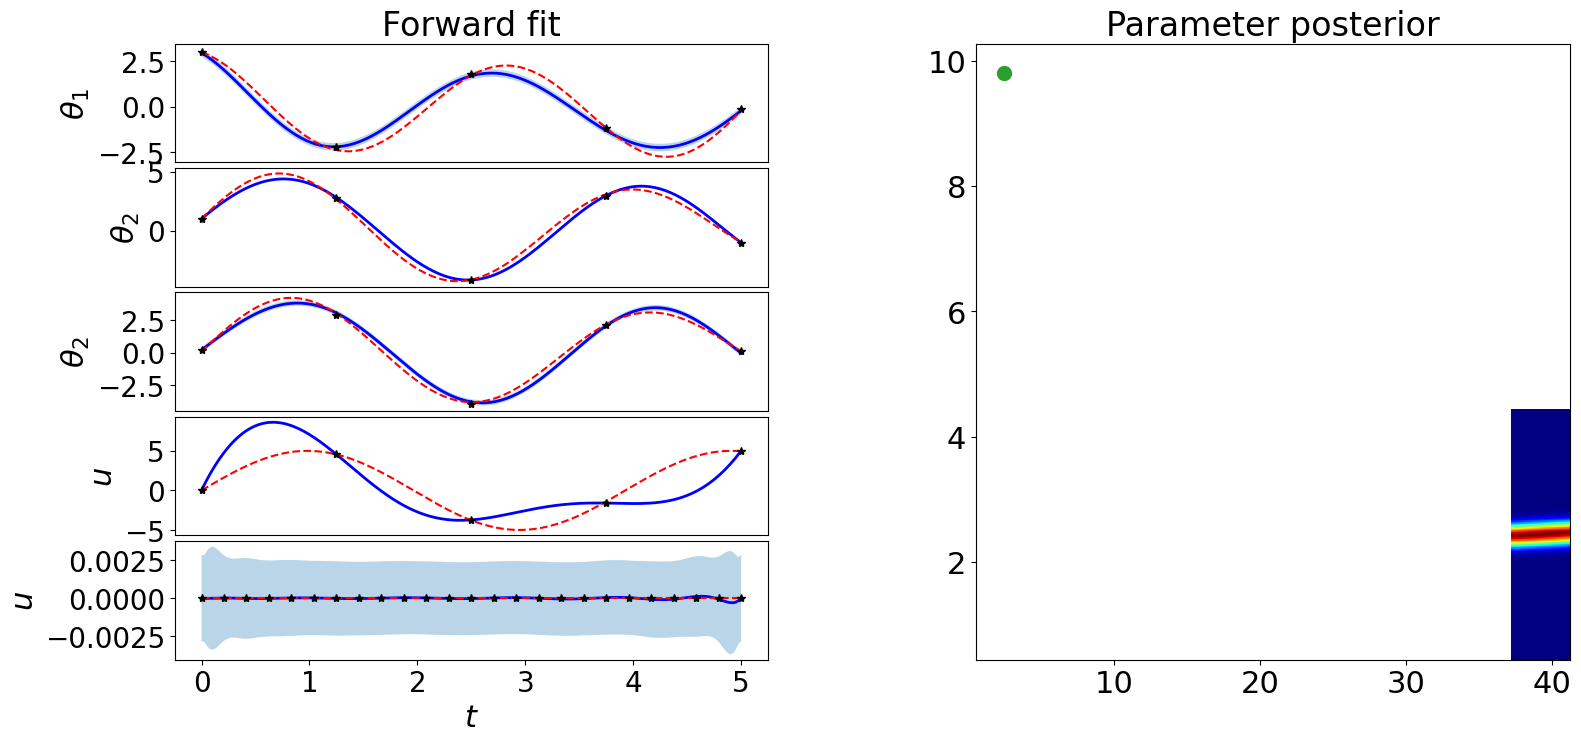

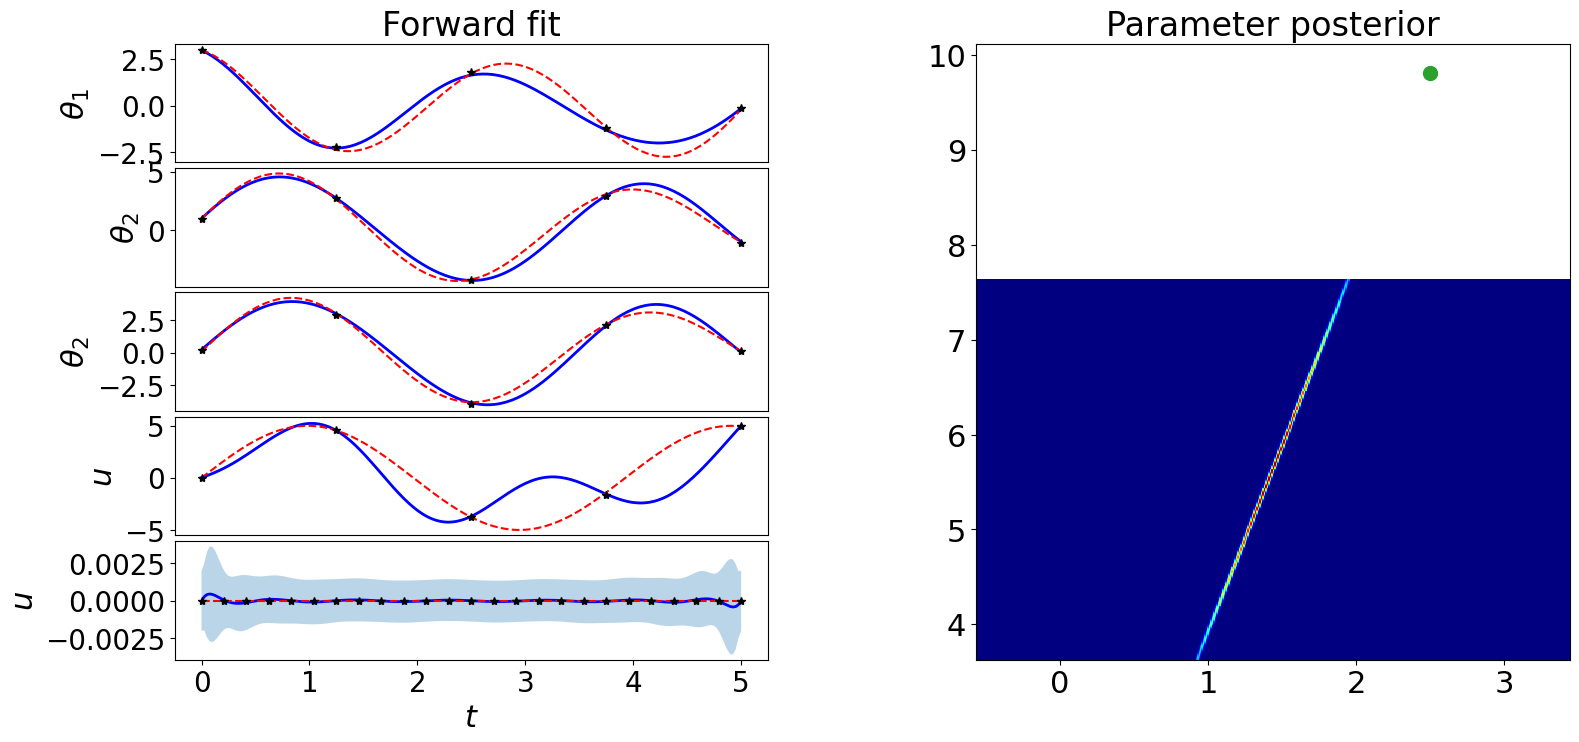

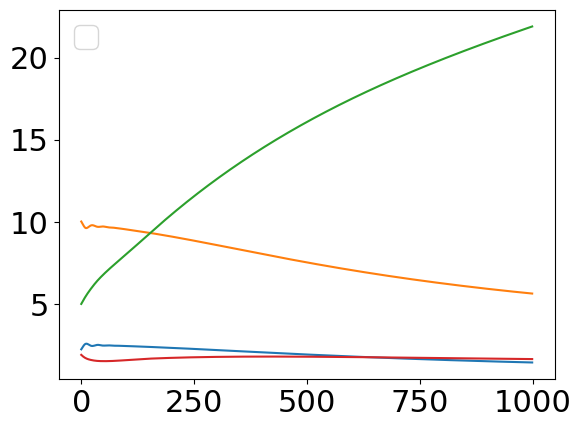

In [5]:
sigma = 0.1
npoints = 5
run = 0

mode = "GT"
title = "GT"
num_tasks = 5

Al_mode = "withAl"
sigma_mode = "extraGTsigma"
point_mode = "extraGTpoints"

cmap = "jet"
for run in range(3, 5):    
    fig = plt.figure(figsize=(18, 8), constrained_layout=True)
    #plt.suptitle(f"{mode}, n={npoints}, σ={sigma}")
    
    task_labels = [r"$\theta_1$", r"$\theta_2$", r"$\theta_2$", r"$u$", r"$u$", r"$u$"]
    
    outer = gridspec.GridSpec(1, 2, width_ratios=[4,4], wspace=0.35)
    
    # ----------------- Load dataset -----------------
    if mode == "GT":
        data_ex2 = np.load(os.path.join(
            data_dir_ex2, Al_mode, sigma_mode, point_mode,
            f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"
        ))
    else:
        data_ex2 = np.load(os.path.join(
            data_dir_ex2, Al_mode, 
            f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"
        ))
        
    for key in data_ex2:
        globals()[key] = torch.tensor(data_ex2[key])
        #print(key)
    # ----------------- LEFT BLOCK: stacked time series -----------------
    inner = gridspec.GridSpecFromSubplotSpec(num_tasks, 1, subplot_spec=outer[0], hspace=0.05)
    
    for i in range(num_tasks):
    
        ax = fig.add_subplot(inner[i,0])
    
        ax.plot(test_x, mean[:,i], 'b', linewidth=2)
        ax.fill_between(test_x, lower[:,i], upper[:,i], alpha=0.3)
    
        ax.plot(test_x, test_y[:,i], "r--")
    
        mask = ~torch.isnan(train_y[:,i])
        ax.plot(train_x[mask], train_y[mask,i], 'k*')
    
        ax.set_ylabel(task_labels[i], fontsize=22)
    
        if i < num_tasks-1:
            ax.tick_params(labelbottom=False, bottom=False, labelsize=20)
        else:
            ax.set_xlabel(r"$t$", fontsize=22)
            ax.tick_params(labelsize=20)
    
        if i == 0:
            ax.set_title("Forward fit", fontsize=24)
    
    # ----------------- RIGHT BLOCK: parameter posterior -----------------
    ax_laplace = fig.add_subplot(outer[1])
    
    N = 400
    
    
    
    xlim = (learned_parameters[0]-2, learned_parameters[0]+2)
    ylim = (learned_parameters[1]-2, learned_parameters[1]+2)
    
    mesh_1 = torch.linspace(xlim[0], xlim[1], N)
    mesh_2 = torch.linspace(ylim[0], ylim[1], N)
    
    param1, param2 = torch.meshgrid(mesh_1, mesh_2, indexing="xy")
    
    mu = learned_parameters[:2]
    
    inv_cov = torch.inverse(laplace_covariance[:2,:2])
    
    param_vec = torch.stack([param1.flatten(), param2.flatten()], dim=-1)
    
    exponent_raw = torch.einsum(
            'bi,ij,bj->b',
            param_vec - mu,
            inv_cov,
            param_vec - mu
        )
    
    prob_density = torch.exp(-0.5*(exponent_raw - exponent_raw.min()))
    prob_density /= prob_density.sum()*(mesh_1[1]-mesh_1[0])*(mesh_2[1]-mesh_2[0])
    
    prob_density = prob_density.reshape(N,N)
    
    surf = ax_laplace.pcolormesh(
            param1, param2, prob_density,
            cmap=cmap,
            shading="auto"
        )
    
    ax_laplace.plot(true_parameters[0], true_parameters[1], color = "C2", marker = "o",  markersize = 10)
        #ax_laplace.plot(learned_parameters[0], learned_parameters[1], "rx")
    
    ax_laplace.set_title("Parameter posterior", fontsize=24)
    

#plt.savefig(os.path.join(save_dir, "Ex2_PoC.png"), dpi=300,bbox_inches='tight' )

plt.figure()
#print(parameters_during_training)
for i in range(parameters_during_training[:,0].shape[0]):#n(used_parameters)):
    plt.plot(range(len(parameters_during_training[i,:])), parameters_during_training[i,:])
plt.legend()